# Simple Linear Regression: Foundations, Predictions, Errors, and Cost

## Goal

Understand your first regression algorithm from the ground up. By the end, you will be able to:

- identify a supervised regression problem;
- distinguish the independent feature from the dependent target;
- read the hypothesis $h_\theta(x)=\theta_0+\theta_1x$;
- explain slope, intercept, prediction, residual, and best-fit line;
- calculate the linear-regression cost by hand and in Python;
- understand the cost curve and its global minimum;
- fit and evaluate a simple line on a small dataset.

**Source material:** the supplied *Simple Linear Regression* transcript and slides. Repeated speech and video filler have been removed. Mathematical slips are corrected where necessary.


## 1. What problem does simple linear regression solve?

**Supervised learning** means that every training example has an input and a known correct output.

**Regression** means that the output is a continuous number, such as height, price, temperature, or salary.

Simple linear regression uses:

- exactly **one input feature** $x$;
- one continuous target $y$;
- a straight line to describe their relationship.

Example: use a person's weight to predict height.

| Term | In the example | Meaning |
|---|---|---|
| Independent feature $x$ | Weight in kg | Input supplied to the model |
| Dependent target $y$ | Height in cm | Correct output to learn/predict |
| Training row $(x^{(i)},y^{(i)})$ | $(74,170)$ | One observed example |
| Prediction $\hat y$ | Predicted height | Model's output for a weight |

If there are several input features, the method becomes **multiple linear regression**. The same main ideas still apply, but there is one coefficient per feature.


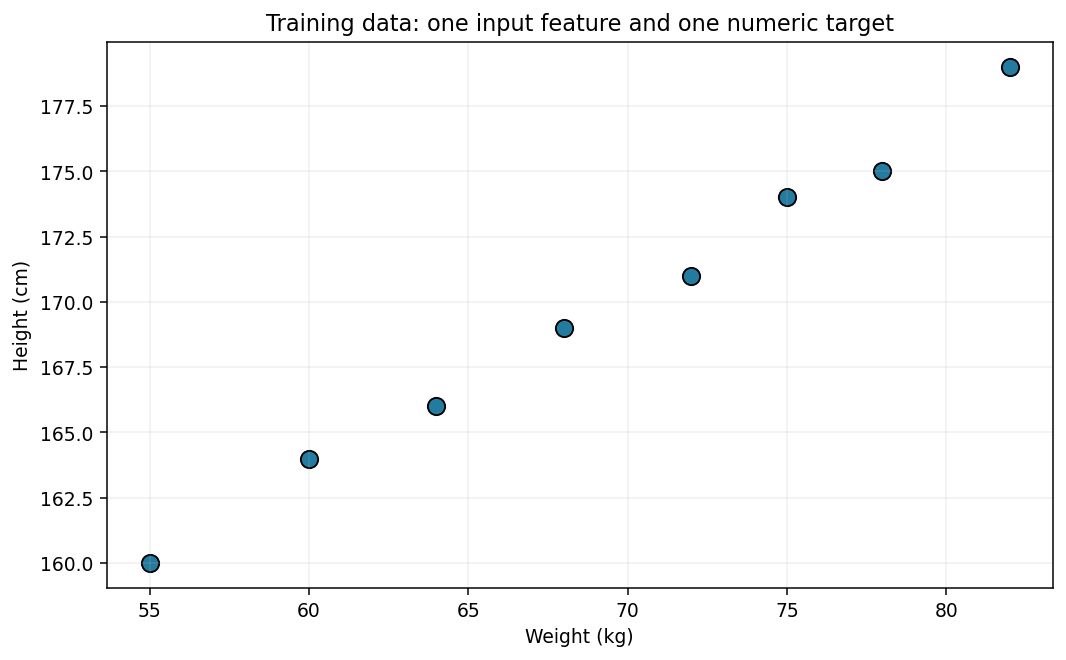

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Small illustrative data (not medical guidance)
weight = np.array([55, 60, 64, 68, 72, 75, 78, 82], dtype=float)
height = np.array([160, 164, 166, 169, 171, 174, 175, 179], dtype=float)

plt.figure(figsize=(8, 5))
plt.scatter(weight, height, s=85, color="#247BA0", edgecolor="black")
plt.xlabel("Weight (kg)")
plt.ylabel("Height (cm)")
plt.title("Training data: one input feature and one numeric target")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## 2. The hypothesis or prediction equation

The straight-line model can be written in several equivalent ways:

$$y=mx+c$$

$$y=\beta_0+\beta_1x$$

$$\boxed{h_\theta(x)=\theta_0+\theta_1x}$$

For predictions, $h_\theta(x)$ is also written as $\hat y$ (“y-hat”):

$$\hat y=\theta_0+\theta_1x$$

The notation means:

- $x$: the independent input feature;
- $\theta_0$: the intercept or bias;
- $\theta_1$: the slope or coefficient;
- $\hat y$: the predicted output;
- $y$: the observed true output.

### Intercept $\theta_0$

When $x=0$, $\hat y=\theta_0$. Geometrically, this is where the line crosses the $y$-axis. Whether $x=0$ is meaningful in the real problem is a separate question.

### Slope $\theta_1$

$\theta_1$ is the predicted change in $y$ for a one-unit increase in $x$:

$$\theta_1=\frac{\text{change in predicted }y}{\text{change in }x}$$

If $\theta_1=0.6$ cm/kg, increasing weight by 1 kg increases predicted height by 0.6 cm.


In [2]:
theta_0 = 128.0
theta_1 = 0.60
new_weight = 74.0
predicted_height = theta_0 + theta_1 * new_weight

print(f"Prediction equation: height = {theta_0} + {theta_1} × weight")
print(f"Predicted height at {new_weight:.0f} kg: {predicted_height:.1f} cm")


Prediction equation: height = 128.0 + 0.6 × weight
Predicted height at 74 kg: 172.4 cm


## 3. What is the best-fit line?

Many different lines can be drawn through a scatter plot. Linear regression chooses the line whose predictions are collectively closest to the observed targets under a chosen loss/cost rule.

For row $i$:

$$\hat y^{(i)}=\theta_0+\theta_1x^{(i)}$$

A **residual** is the vertical prediction error. Two sign conventions are common:

$$e^{(i)}=y^{(i)}-\hat y^{(i)}$$

or

$$r^{(i)}=\hat y^{(i)}-y^{(i)}$$

They have opposite signs but the same square. State your convention and use it consistently.

Simply adding raw residuals is not a reliable cost: positive and negative errors can cancel. Squaring prevents cancellation and penalizes large mistakes more strongly.


Fitted line: height = 122.869 + 0.677 × weight
Residuals (true - predicted): [-0.1, 0.51, -0.2, 0.1, -0.61, 0.36, -0.67, 0.62]


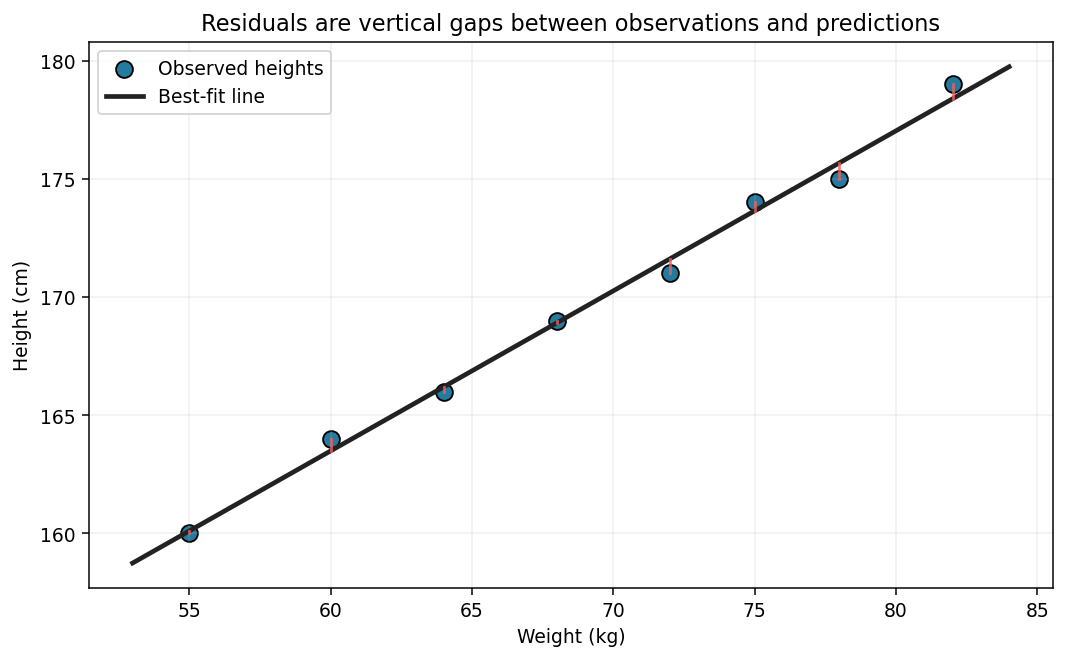

In [3]:
# Fit the teaching data using NumPy's least-squares polynomial fit
fitted_slope, fitted_intercept = np.polyfit(weight, height, 1)
predictions = fitted_intercept + fitted_slope * weight
residuals = height - predictions

print(f"Fitted line: height = {fitted_intercept:.3f} + {fitted_slope:.3f} × weight")
print("Residuals (true - predicted):", np.round(residuals, 2).tolist())

x_line = np.linspace(53, 84, 200)
y_line = fitted_intercept + fitted_slope * x_line

plt.figure(figsize=(8, 5))
plt.scatter(weight, height, s=80, color="#247BA0", edgecolor="black", label="Observed heights")
plt.plot(x_line, y_line, color="#222222", linewidth=2.5, label="Best-fit line")
for x_i, y_i, y_hat_i in zip(weight, height, predictions):
    plt.plot([x_i, x_i], [y_i, y_hat_i], color="#F25F5C", linewidth=1.5, alpha=0.8)
plt.xlabel("Weight (kg)")
plt.ylabel("Height (cm)")
plt.title("Residuals are vertical gaps between observations and predictions")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()


## 4. The cost function

For $m$ training examples, the lesson uses:

$$
\boxed{J(\theta_0,\theta_1)=\frac{1}{2m}\sum_{i=1}^{m}\left(h_\theta(x^{(i)})-y^{(i)}\right)^2}
$$

This is the **half mean squared error**:

$$J=\frac{1}{2}\operatorname{MSE}$$

The factor $1/2$ is included because it cancels the `2` produced when differentiating a square. It does not change which parameters minimize the cost.

Why each part is present:

- prediction minus truth gives a residual;
- squaring makes every contribution non-negative and emphasizes large errors;
- summing combines all rows;
- dividing by $m$ makes the value an average;
- dividing by 2 simplifies later derivatives.

Training means choosing $\theta_0$ and $\theta_1$ that minimize $J$.


In [4]:
def predict(x, theta_0, theta_1):
    return theta_0 + theta_1 * np.asarray(x, dtype=float)


def half_mse_cost(x, y, theta_0, theta_1):
    errors = predict(x, theta_0, theta_1) - np.asarray(y, dtype=float)
    return np.mean(errors ** 2) / 2


cost = half_mse_cost(weight, height, fitted_intercept, fitted_slope)
mse = 2 * cost
rmse = np.sqrt(mse)
mae = np.mean(np.abs(predictions - height))

print(f"Half-MSE cost J: {cost:.4f}")
print(f"MSE:             {mse:.4f}")
print(f"RMSE:            {rmse:.4f} cm")
print(f"MAE:             {mae:.4f} cm")


Half-MSE cost J: 0.1037
MSE:             0.2073
RMSE:            0.4553 cm
MAE:             0.3960 cm


## 5. Worked example from the transcript

Use three points:

$$ (1,1),\ (2,2),\ (3,3) $$

To make the first cost graph two-dimensional, fix the intercept at $\theta_0=0$. Then:

$$h_\theta(x)=\theta_1x$$

### Case A: $\theta_1=1$

Predictions are $1,2,3$. Every residual is zero:

$$J(1)=\frac{(1-1)^2+(2-2)^2+(3-3)^2}{2\cdot3}=0$$

### Case B: $\theta_1=0.5$

Predictions are $0.5,1,1.5$:

$$J(0.5)=\frac{(0.5-1)^2+(1-2)^2+(1.5-3)^2}{6}=0.5833$$

### Case C: $\theta_1=0$

Predictions are $0,0,0$:

$$J(0)=\frac{(0-1)^2+(0-2)^2+(0-3)^2}{6}=2.3333$$

The line with $\theta_1=1$ is best for these exact points because its cost is zero.


In [5]:
x_small = np.array([1.0, 2.0, 3.0])
y_small = np.array([1.0, 2.0, 3.0])

for slope in [1.0, 0.5, 0.0]:
    y_hat = predict(x_small, 0.0, slope)
    j = half_mse_cost(x_small, y_small, 0.0, slope)
    print(f"theta_1={slope:>3}: predictions={y_hat.tolist()}, J={j:.4f}")


theta_1=1.0: predictions=[1.0, 2.0, 3.0], J=0.0000
theta_1=0.5: predictions=[0.5, 1.0, 1.5], J=0.5833
theta_1=0.0: predictions=[0.0, 0.0, 0.0], J=2.3333


## 6. The cost curve

For the three-point example with $\theta_0=0$:

$$
J(\theta_1)=\frac{1}{6}\left[(\theta_1-1)^2+(2\theta_1-2)^2+(3\theta_1-3)^2\right]
$$

$$
J(\theta_1)=\frac{14}{6}(\theta_1-1)^2
$$

This is a U-shaped quadratic curve. Its lowest point is the **global minimum**, $\theta_1=1$.

> The curve is the **cost function plotted against a parameter**. Gradient descent is the algorithm that moves along this curve toward its minimum; the curve itself is not “gradient descent.”


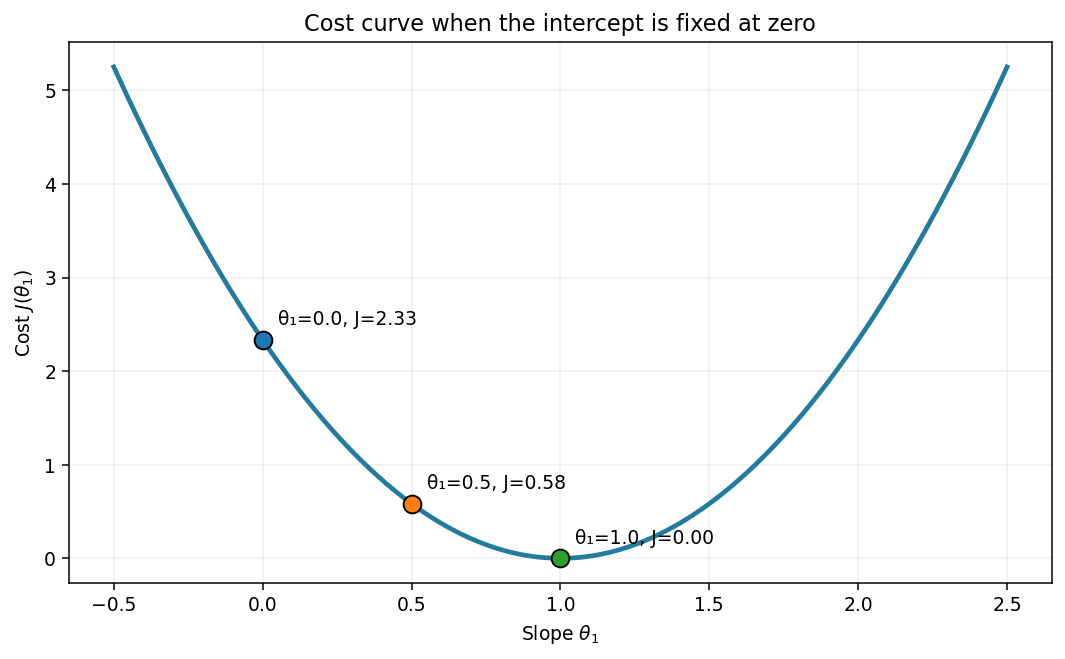

In [6]:
slope_values = np.linspace(-0.5, 2.5, 300)
cost_values = [half_mse_cost(x_small, y_small, 0.0, slope) for slope in slope_values]

plt.figure(figsize=(8, 5))
plt.plot(slope_values, cost_values, color="#247BA0", linewidth=2.5)
for slope in [0.0, 0.5, 1.0]:
    plt.scatter(slope, half_mse_cost(x_small, y_small, 0.0, slope),
                s=90, edgecolor="black", zorder=3)
    plt.annotate(f"θ₁={slope}, J={half_mse_cost(x_small, y_small, 0.0, slope):.2f}",
                 (slope, half_mse_cost(x_small, y_small, 0.0, slope)),
                 xytext=(8, 8), textcoords="offset points")
plt.xlabel(r"Slope $\theta_1$")
plt.ylabel(r"Cost $J(\theta_1)$")
plt.title("Cost curve when the intercept is fixed at zero")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## 7. MSE, RMSE, and MAE

| Metric | Formula | Main interpretation |
|---|---|---|
| Half-MSE cost | $\frac{1}{2m}\sum r_i^2$ | Convenient for optimization derivatives |
| MSE | $\frac{1}{m}\sum r_i^2$ | Average squared error; strongly penalizes large errors |
| RMSE | $\sqrt{\frac{1}{m}\sum r_i^2}$ | Error in the same unit as the target |
| MAE | $\frac{1}{m}\sum |r_i|$ | Average absolute error; less sensitive to large outliers than MSE |

The transcript introduces these alternatives but trains with squared error. Different loss functions can produce different best-fit parameters.


## 8. Advanced but useful: direct least-squares solution

For simple linear regression with an intercept, the least-squares optimum can be calculated directly:

$$
\theta_1=\frac{\sum_i(x^{(i)}-\bar x)(y^{(i)}-\bar y)}{\sum_i(x^{(i)}-\bar x)^2}
$$

$$
\theta_0=\bar y-\theta_1\bar x
$$

This produces the same best-fit line as minimizing squared error with a converged optimizer, apart from numerical precision. Gradient descent is still essential because the same optimization idea extends to models where a simple closed-form solution is inconvenient or unavailable.


In [7]:
x_mean = weight.mean()
y_mean = height.mean()
closed_form_slope = np.sum((weight - x_mean) * (height - y_mean)) / np.sum((weight - x_mean) ** 2)
closed_form_intercept = y_mean - closed_form_slope * x_mean

print(f"Closed-form intercept: {closed_form_intercept:.6f}")
print(f"Closed-form slope:     {closed_form_slope:.6f}")
print("Matches NumPy fit:", np.allclose(
    [closed_form_intercept, closed_form_slope],
    [fitted_intercept, fitted_slope]
))


Closed-form intercept: 122.868619
Closed-form slope:     0.676987
Matches NumPy fit: True


## 9. Assumptions and cautions

- **Linear pattern:** a straight line should be a reasonable summary of the average relationship.
- **Independent observations:** one row should not secretly duplicate or depend on another in a way the analysis ignores.
- **Stable residual spread:** for classical inference, residual variance should be reasonably constant across $x$.
- **Outliers matter:** squared error gives very large residuals strong influence.
- **Extrapolation is risky:** predictions far outside the training range may be unrealistic.
- **Association is not causation:** a fitted relationship does not prove that changing $x$ causes $y$ to change.
- **Prediction performance must be tested:** low training cost alone does not guarantee good performance on unseen data.


## 10. Quick revision sheet

- **Simple linear regression:** one input feature, one continuous output, one fitted straight line.
- **Hypothesis:** $h_\theta(x)=\theta_0+\theta_1x$.
- **Prediction:** $\hat y=h_\theta(x)$.
- **Intercept:** $\theta_0$, the predicted value at $x=0$.
- **Slope:** $\theta_1$, predicted change in $y$ for a one-unit increase in $x$.
- **Residual:** difference between observed and predicted output.
- **Best-fit line:** parameters that minimize the chosen cost on training data.
- **Linear-regression cost:** $J=\frac{1}{2m}\sum(\hat y-y)^2$.
- **Global minimum:** the lowest attainable point on the cost surface.
- **Multiple linear regression:** several input features and one coefficient per feature.


## 11. Quick questions — answer before checking below

1. What type of output does regression predict?
2. Why is this method called *simple* linear regression?
3. In the weight-height example, which variable is independent and which is dependent?
4. Write the hypothesis equation used in the lesson.
5. What does $\theta_0$ represent?
6. What does $\theta_1$ represent?
7. What is another notation for $h_\theta(x)$?
8. What is a residual?
9. Why should we not minimize the simple sum of signed residuals?
10. Write the half-MSE cost function.
11. Why is there a factor of $1/2$ in the cost?
12. For $(1,1),(2,2),(3,3)$, $\theta_0=0$, and $\theta_1=1$, what is $J$?
13. For the same data and $\theta_1=0.5$, what is $J$?
14. Is the U-shaped plot itself gradient descent?
15. Why can a line with low training cost still perform poorly in practice?


## 12. Answer key

1. A continuous numeric value.
2. It uses exactly one independent input feature.
3. Weight is the independent input; height is the dependent target.
4. $h_\theta(x)=\theta_0+\theta_1x$.
5. The intercept/bias: the predicted $y$ value when $x=0$.
6. The slope/coefficient: predicted change in $y$ per one-unit increase in $x$.
7. $\hat y$ (“y-hat”).
8. The vertical difference between an observed target and its prediction.
9. Positive and negative residuals can cancel even when individual errors are large.
10. $J(\theta_0,\theta_1)=\frac{1}{2m}\sum_{i=1}^{m}(h_\theta(x^{(i)})-y^{(i)})^2$.
11. It cancels the factor 2 during differentiation and does not change the minimizer.
12. $0$.
13. $0.5833$ approximately.
14. No. It is the cost curve; gradient descent is an algorithm that moves along it toward the minimum.
15. The model can overfit unusual training data, violate the linear assumption, face distribution shift, or be judged only on seen examples.
